In [54]:
from jax.lax import integer_pow_p
import jax 

import numpy as np

import jax.numpy as jnp
import jax.random as jrandom
from jax import lax

from jax.scipy.optimize import minimize

from probjax.distributions import MultivariateNormal
from probjax.core.jaxpr_propagation.graph import JaxprGraph

import matplotlib.pyplot as plt

from sbi.analysis import pairplot

In [55]:
x = jnp.array([0.5])
W1 = jrandom.normal(jrandom.PRNGKey(1), (100,1)) 
W2 = jrandom.normal(jrandom.PRNGKey(2), (1, 100)) 
b1 = jrandom.normal(jrandom.PRNGKey(42), (100,))  * 0.1

U, S, V_T = jnp.linalg.svd(W1)
U1, S1, V_T1= jnp.linalg.svd(W2)
effective_dim = jnp.sum(S > 1e-5)
effective_dim1 = jnp.sum(S1 > 1e-5)
print(effective_dim, effective_dim1)

# Projection matrix
W_norm = jnp.linalg.norm(W1, axis=0, keepdims=True)
W_normed = W1 / W_norm
P = W_normed @ W_normed.T

1 1


In [56]:
def f(x):
    y1 = W1 @ x
    y2 = y1 + b1
    y3 = jax.nn.leaky_relu(y2, negative_slope=0.1)
    y4 = W2 @ y3
    return y4#, (y1, y2, y3,)

def f_inv(y4, theta1, theta2):
    # By assumption y4 is output of f(x) and thus in the image space of W2
    y3 = jnp.linalg.pinv(W2) @ y4 + V_T1.T[:,effective_dim:] @ jnp.atleast_1d(theta1) # 49 dim vector of free parameters
    # _y3 = jnp.clip(y3,-1 + 1e-7, 1 - 1e-7)
    # error = jnp.mean(jnp.abs(_y3- y3))
    # y3 = jax.lax.cond(error == 0., lambda : y3, lambda : _y3)
    y2 = jax.nn.leaky_relu(y3, negative_slope=10.)
    y1 = y2 - b1
    _y1 = P @ y1 # Must be in image space of W1
    error = jnp.sum(jnp.abs(_y1 - y1))
    y1 = jax.lax.cond(error < 1e-4, lambda : y1, lambda : _y1)
    x = jnp.linalg.pinv(W1) @ y1 #+ V_T.T[:,:effective_dim] @ jnp.atleast_1d(theta2)
    return x, error#, (y1, y2, y3,)

In [90]:
y1 = W1 @ x
y2 = y1 + b1
y3 = jax.nn.leaky_relu(y2, negative_slope=0.1)
y4 = W2 @ y3

In [114]:
def _loss_fn(theta1):
    y3_ = jnp.linalg.pinv(W2) @ y4 + V_T1.T[:,effective_dim:] @ jnp.atleast_1d(theta1) # 49 dim vector of free parameters
    return jnp.mean((y3_ - y3)**2)

def _loss_fn2(theta2):
    x_ = jnp.linalg.pinv(W1) @ y1 + V_T.T[:,:effective_dim] @ jnp.atleast_1d(theta2)
    return jnp.mean((x_ - x)**2)


# def _loss_fn(theta1):
#     y3_ = jnp.linalg.pinv(W2) @ y4 + V_T1.T[:,effective_dim:] @ jnp.atleast_1d(theta1) # 49 dim vector of free parameters
#     y2_ = jax.nn.leaky_relu(y3_, negative_slope=10.)
#     y1_ = y2_ - b1
#     _y1_ = P @ y1_ # Must be in image space of W1
#     error = jnp.mean((_y1_ - y1_)**2)
#     return error



In [115]:
theta1 = minimize(_loss_fn, 0.1*jnp.ones((99)), method='BFGS').x 
theta2 = minimize(_loss_fn2, jnp.ones((1)), method='BFGS').x  #+ 2
y3_ = jnp.linalg.pinv(W2) @ y4 + V_T1.T[:,effective_dim:] @ jnp.atleast_1d(theta1) # 49 dim vector of free parameters
y2_ = jax.nn.leaky_relu(y3_, negative_slope=10.)
y1_ = y2_ - b1
error = jnp.mean(jnp.abs((y1_ - P@y1_)))
x_ = jnp.linalg.pinv(W1) @ y1_ #+ V_T.T[:,:effective_dim] @ jnp.atleast_1d(theta2)

x_ - x

Array([0.], dtype=float32)

In [116]:
error

Array(0., dtype=float32)

In [111]:
f_inv(y4, theta1, theta2)

(Array([0.336], dtype=float32), Array(14.019, dtype=float32))

In [61]:
# For a single observation
from jax.scipy.optimize import minimize

# Define x
x = jnp.array([2.5])
y = f(x)

@jax.jit
def loss_fn(thetas):
    theta1 = thetas[: -1]
    theta2 = thetas[-1:]
    y3 = f(x)
    x_hat, error = f_inv(y3, theta1, theta2)
    return  jnp.sum((x_hat - x)**2)

result = minimize(loss_fn, 0.1*jnp.ones(100), method="BFGS", tol=1e-8)
result.fun

Array(0., dtype=float32)

In [62]:
# There are parameters that can perfectly reconstruct the input!
# However, the reconstruction is not unique.
theta1 = result.x[: -1]
theta2 = result.x[-1:]
x_rec, error = f_inv(y, theta1= theta1, theta2 = theta2)
y_rec = f(x_rec)

print(y_rec, y)
print(x_rec, x)

[15.929] [15.929]
[2.5] [2.5]


In [67]:
# For all x this is not possible as the function is not invertible
# We thus need a stochastic inverse!

# We can keep the structure but 

import haiku as hk

@hk.without_apply_rng
@hk.transform
def net(eps, y):
    #input = jnp.concatenate([eps, y])

    input = jnp.concatenate([eps, y*jnp.ones((1,100))], axis=-1)
    return hk.nets.MLP([200, 200,200, 100])(input)

params = net.init(jrandom.PRNGKey(0), jnp.ones((1,100)), jnp.ones((1,1)))
g = net.apply

In [68]:
def sliced_wasserstein2_distance(key, xs, ys, num_projections=100):
    """
    Computes the Sliced Wasserstein-2 distance between two sets of samples.

    Args:
        key: jax.random.PRNGKey
        xs: jnp.ndarray, shape (n, d)
        ys: jnp.ndarray, shape (m, d)
        num_projections: int, number of projections to use
    
    Returns:
        swd: float, sliced wasserstein distance
    """

    # Generate random projections
    projections = jax.random.normal(key, shape=(num_projections, xs.shape[1]))

    # Compute projections
    xs_projections = jnp.dot(xs, projections.T)
    ys_projections = jnp.dot(ys, projections.T)

    # Sort projections
    xs_projections = jnp.sort(xs_projections, axis=0)
    ys_projections = jnp.sort(ys_projections, axis=0)

    # Compute sliced wasserstein distance
    swd = jnp.sqrt(jnp.sum((xs_projections - ys_projections) ** 2)) / num_projections

    return swd

In [71]:
import optax 

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

def loss_fn(params, key):
    key1, key2 = jrandom.split(key)
    xs = jrandom.normal(key1, (500,1))*2
    y3 = jax.vmap(f)(xs)
    eps = jrandom.normal(key2, (xs.shape[0],100))
    thetas = g(params, eps, y3)
    theta1 = thetas[: ,: -1]
    theta2 = thetas[: ,-1:]
    x_hat, error = jax.vmap(f_inv, in_axes=(0, 0,0))(y3, theta1, theta2)
    # kxx = jnp.exp(-(xs - xs.T)**2/0.1)
    # kyy = jnp.exp(-(x_hat - x_hat.T)**2/0.1)
    # kxy = jnp.exp(-(xs - x_hat.T)**2/0.1)

    return jnp.mean(error) #+ 10*sliced_wasserstein2_distance(key, xs, x_hat, num_projections=1)

@jax.jit
def update(params, opt_state, key):
    grads = jax.grad(loss_fn)(params, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state

In [75]:
key = jrandom.PRNGKey(0)
for i in range(10000):
    key, subkey = jrandom.split(key)
    params, opt_state = update(params, opt_state, subkey)
    if i % 1000 == 0:
        print(loss_fn(params, subkey))

1.9133971
1.7039223
1.7300547
1.7619605
1.7828149
1.4680083
1.5652783
1.7283256
1.6211802
1.4892718


In [76]:
xs = jrandom.normal(key+ 10, (1000,1))
y3 = jax.vmap(f)(xs)
eps = jrandom.normal(key + 1, (xs.shape[0],100))
thetas = g(params, eps, y3)
theta1 = thetas[: ,: -1]
theta2 = thetas[: ,-1:]
x_hat, error = jax.vmap(f_inv, in_axes=(0, 0,0))(y3, theta1, theta2)
jnp.mean(error)

Array(0.716, dtype=float32)

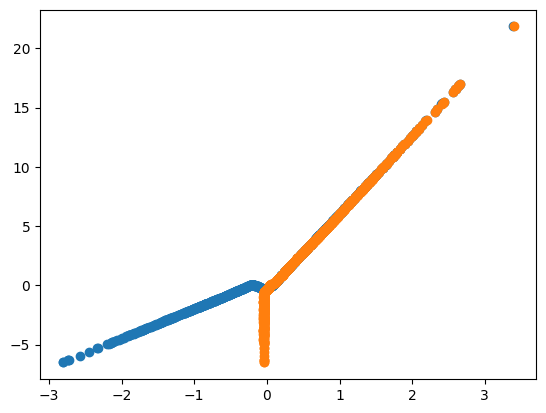

In [81]:
plt.scatter(xs, y3)
plt.scatter(x_hat, y3)

In [19]:
y = f(x)

thetas = g(params, eps, jnp.ones_like(y3)*y)
theta1 = thetas[: ,: -1]
theta2 = thetas[: ,-1:]
x_rec, error = jax.vmap(f_inv, in_axes=(None, 0,0))(y, theta1, theta2)
y_rec = jax.vmap(f)(x_rec)

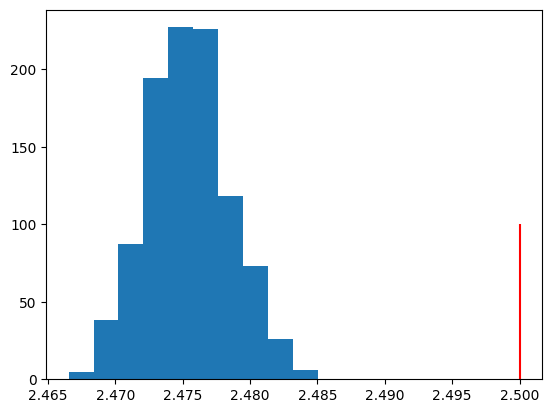

In [20]:
_ = plt.hist(x_rec.reshape(-1))
plt.vlines(x, 0, 100, color="red")

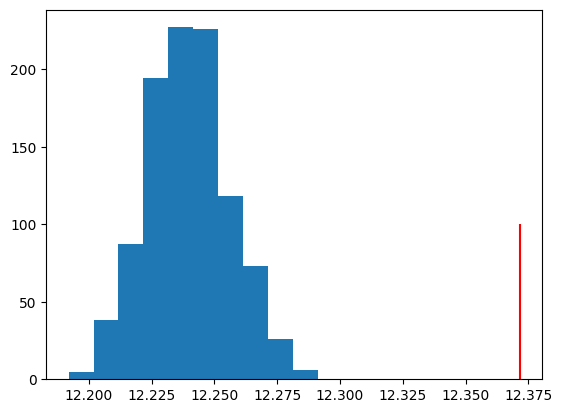

In [21]:
_ = plt.hist(y_rec.reshape(-1))
plt.vlines(y, 0, 100, color="red")